## Exercise 6: Choosing the best performing model on a dataset

Instructions:

- Use the Dataset File to train your model
- Use the Test File to generate your results
- Use the Sample Submission file to generate the same format
- Use all Regression models

Submit your results to:
https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview



In [ ]:
import pandas as pd
import seaborn as sns

from matplotlib import pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

## Dataset File

In [ ]:
train_data = 'https://github.com/robitussin/CCMACLRL_EXERCISES/blob/3fd7d51ffd17863598ac3f44eeefc558171a5b73/dataset/house-prices-advanced-regression-techniques/train.csv?raw=true'
df = pd.read_csv(train_data)

## Test File

In [37]:
# Load the test data again
test_url = 'https://github.com/robitussin/CCMACLRL_EXERCISES/blob/3fd7d51ffd17863598ac3f44eeefc558171a5b73/dataset/house-prices-advanced-regression-techniques/test.csv?raw=true'
dt = pd.read_csv(test_url)

In [ ]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

## Sample Submission File

In [ ]:
sample_submission_url ='https://github.com/robitussin/CCMACLRL_EXERCISES/blob/3fd7d51ffd17863598ac3f44eeefc558171a5b73/dataset/house-prices-advanced-regression-techniques/sample_submission.csv?raw=true'

sf=pd.read_csv(sample_submission_url)

In [ ]:
sf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         1459 non-null   int64  
 1   SalePrice  1459 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 22.9 KB


In [5]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
df.shape

(1460, 81)

In [8]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


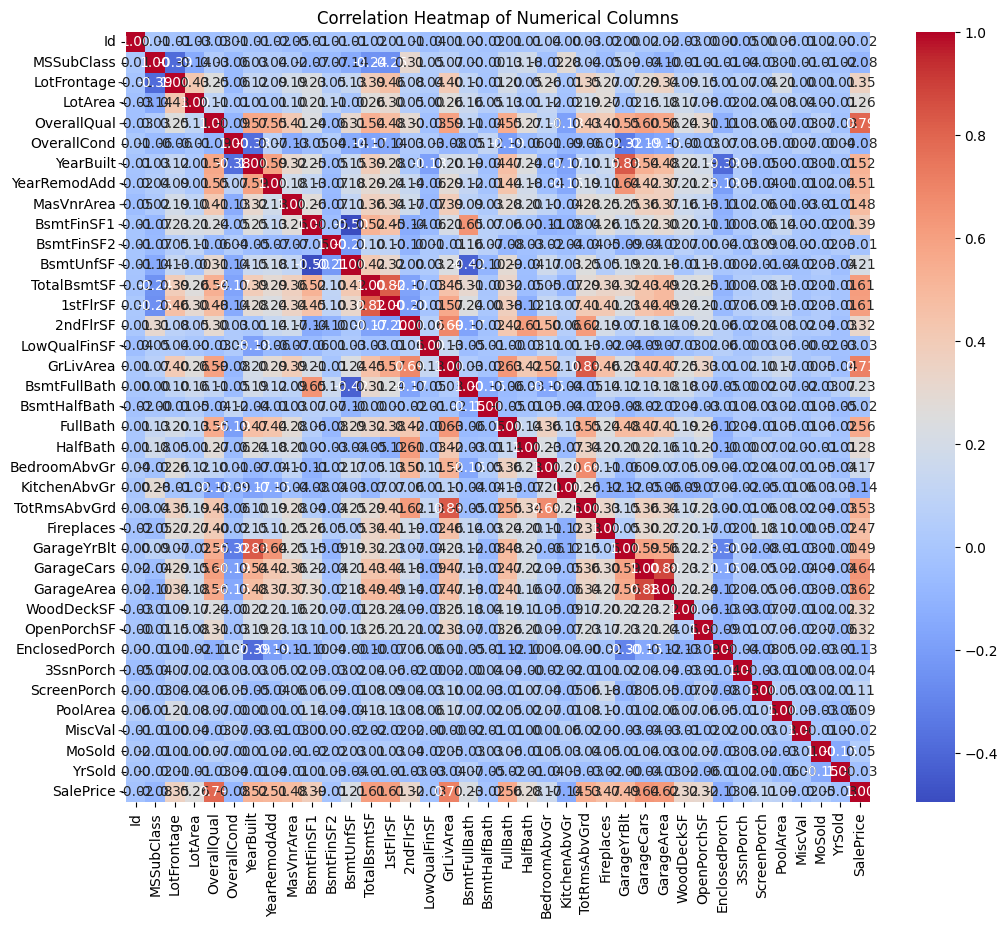

In [10]:
numerical_df = df.select_dtypes(include=['number'])
plt.figure(figsize=(12, 10))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

In [11]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [12]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [13]:
df.select_dtypes(include=['object']).columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [14]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [15]:
df = df.fillna(df.mean(numeric_only=True))

In [16]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [17]:
df.shape

(1460, 81)

In [18]:
x = df[['OverallQual','GrLivArea','GarageCars','TotalBsmtSF','FullBath','YearBuilt']]
y = df['SalePrice']

In [19]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

## 1. Train a KNN Regressor

In [20]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(xtrain, ytrain)
print("KNN Score:", knn.score(xtest, ytest))

KNN Score: 0.7140866408803606


- Perform cross validation

In [27]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation for KNN Regressor
knn_cv_scores = cross_val_score(knn, xtrain, ytrain, cv=5) # Using 5 folds
print("KNN Cross-Validation Scores:", knn_cv_scores)
print("KNN Average Cross-Validation Score:", knn_cv_scores.mean())

KNN Cross-Validation Scores: [0.71216257 0.5669384  0.69562971 0.66479481 0.70049772]
KNN Average Cross-Validation Score: 0.668004641254012


## 2. Train a SVM Regression

In [21]:
svr = SVR()
svr.fit(xtrain, ytrain)
print("SVR Score:", svr.score(xtest, ytest))

SVR Score: -0.02371452399878793


- Perform cross validation

In [26]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation for SVR
svr_cv_scores = cross_val_score(svr, xtrain, ytrain, cv=5) # Using 5 folds
print("SVR Cross-Validation Scores:", svr_cv_scores)
print("SVR Average Cross-Validation Score:", svr_cv_scores.mean())

SVR Cross-Validation Scores: [-0.04526668 -0.11292562 -0.01465645 -0.0314705  -0.05299807]
SVR Average Cross-Validation Score: -0.051463463697463394


## 3. Train a Decision Tree Regression

In [22]:
dtree = DecisionTreeRegressor(random_state=42)
dtree.fit(xtrain, ytrain)
print("Decision Tree Score:", dtree.score(xtest, ytest))

Decision Tree Score: 0.7778040647400769


- Perform cross validation

In [25]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation for Decision Tree Regressor
dtree_cv_scores = cross_val_score(dtree, xtrain, ytrain, cv=5) # Using 5 folds
print("Decision Tree Cross-Validation Scores:", dtree_cv_scores)
print("Decision Tree Average Cross-Validation Score:", dtree_cv_scores.mean())

Decision Tree Cross-Validation Scores: [0.55153211 0.47242124 0.79911764 0.67867154 0.70339189]
Decision Tree Average Cross-Validation Score: 0.6410268817569552


## 4. Train a Random Forest Regression

In [23]:
rforest = RandomForestRegressor(random_state=42)
rforest.fit(xtrain, ytrain)
print("Random Forest Score:", rforest.score(xtest, ytest))

Random Forest Score: 0.890782574538937


## 5. Compare all the performance of all regression models

In [28]:
# Create a dictionary to store the scores
scores = {
    'KNN Regressor': knn.score(xtest, ytest),
    'SVR': svr.score(xtest, ytest),
    'Decision Tree Regressor': dtree.score(xtest, ytest),
    'Random Forest Regressor': rforest.score(xtest, ytest)
}

# Create a pandas DataFrame from the scores
scores_df = pd.DataFrame(scores, index=['Test Score'])

# Display the DataFrame
display(scores_df)

,KNN Regressor,SVR,Decision Tree Regressor,Random Forest Regressor
Test Score,0.714087,-0.023715,0.777804,0.890783


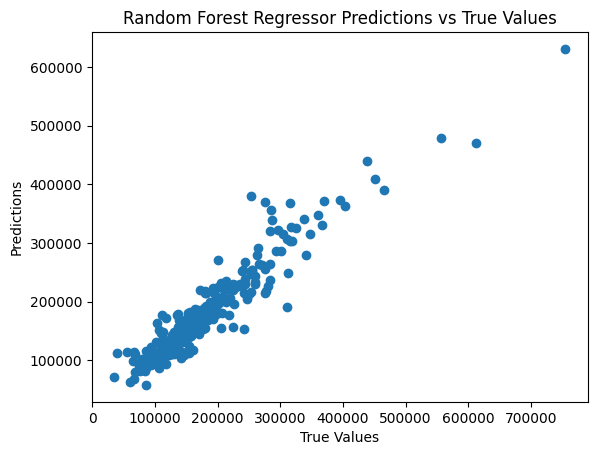

In [29]:
predictions = rforest.predict(xtest)
plt.scatter(ytest, predictions)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("Random Forest Regressor Predictions vs True Values")
plt.show()

## 6. Generate Submission File

Choose the model that has the best performance to generate a submission file.

In [38]:
# Define required features
required_features = ['OverallQual','GrLivArea','GarageCars','TotalBsmtSF','FullBath','YearBuilt']

# Make sure test dataset has all required columns (fill missing with 0)
for col in required_features:
    if col not in dt.columns:
        dt[col] = 0

# Build the submission DataFrame
submission = pd.DataFrame({
    "Id": dt["Id"],
    "SalePrice": rforest.predict(dt[required_features].fillna(0))
})

In [39]:
submission.to_csv('submission.csv', index=False)
print("Submission file created successfully!")

Submission file created successfully!


In [40]:
submission.to_csv("submission.csv", index=False)

In [41]:

from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>